In [1]:
import switchy.CloneStats as cs
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
import scanpy.external as sce
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }

mpl.rcParams.update(params)

sns.set_style("ticks")
sns.set_context(context='paper')
savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": False}
mpl.rc('savefig', dpi=300)
output_dir='figures/9.21.20_PaperDraft/'
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20) 
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

In [2]:
mkdir 'figures/9.21.20_PaperDraft/'

mkdir: cannot create directory ‘figures/9.21.20_PaperDraft/’: File exists


# Load the Data

In [3]:
parameters, io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):


(1350, 10) (14714, 2) shape of adata after filtering 


In [4]:
IgH_genes = ['IGHM', 'IGHD', 'IGHG3', 'IGHG1', 'IGHA1', "IGHG2", 'IGHG4','IGHE', 'IGHA2', 'IGLC3', 'IGKC']


In [295]:
# Select only the B cells I cultured and Activated
selector = adata.obs[adata.obs['Experimental_Label'].str.contains('Activation')].index
df = df[df.index.isin(selector)]
adata_obs = adata.obs[adata.obs.index.isin(df.index)]

In [296]:
adata_obs = adata.obs

# MALAT1 Test Illustration

(982, 11)
(472, 11)


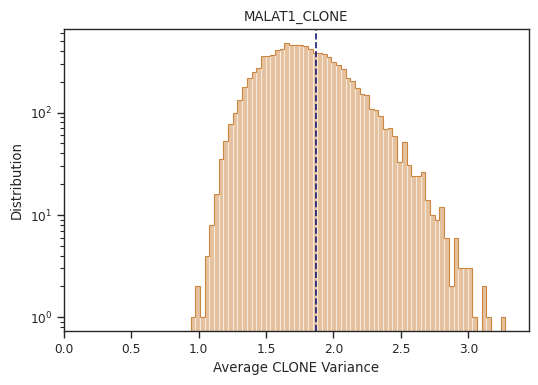

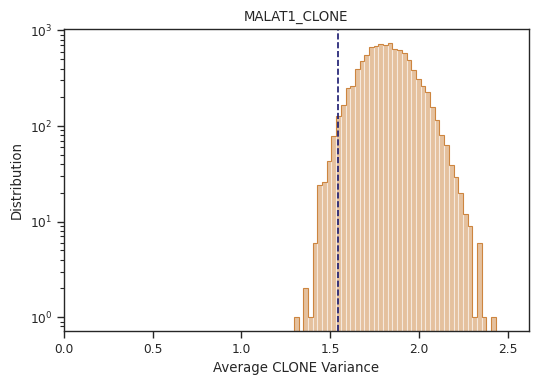

In [297]:
fig1 = cs.plotTestHist(df, adata_obs, 10000, 'MALAT1', 'CLONE', filterzeroes = False)
fig2 = cs.plotTestHist(df, adata_obs, 10000, 'MALAT1', 'CLONE', filterzeroes = True)

In [298]:
save_figure(fig1, "MALAT1_TestHist_WithZeroes", output_dir='../figures/PaperDraft1/')
save_figure(fig2, "MALAT1_TestHist_NoZeroes", output_dir='../figures/PaperDraft1/')

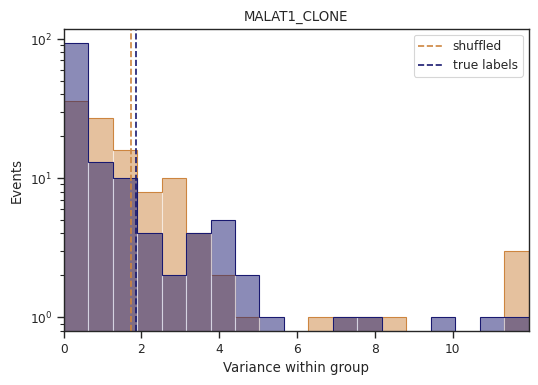

In [299]:
fig, data, data_shuffled = cs.plotEgHists(df, adata_obs, 1, 'MALAT1', 'CLONE')

In [300]:
save_figure(fig, "MALAT1_Shuffled_True_EgHist", output_dir='../figures/PaperDraft1/')

In [7]:
CLONE_tests = pd.read_csv('../outputs/CLONE_tests.csv', index_col = 0)
ENV_tests = pd.read_csv('../outputs/Experimental_Label_tests.csv', index_col = 0)
TREATMENT_tests = pd.read_csv('../outputs/Treatment_tests.csv', index_col = 0)

clonal_genes = list(CLONE_tests[CLONE_tests.corrected_pvalue < 0.01].gene)

In [8]:
def imputeGenes(adata, genes):
    adata_magic = sce.pp.magic(adata, name_list=genes, knn=5)
    

    array = adata_magic.X

    adata_magic.obs.index

    df = pd.DataFrame(array)

    df.index = adata_magic.obs.index

    df.columns = adata_magic.var.index
    
    return df

def scVI(filename):
    adata = sc.read_h5ad(filename)
    sc.pp.filter_cells(adata, min_counts=80000)
    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.calculate_qc_metrics(adata, inplace= True)
    adata = sce.pp.scvi(adata, copy=True)
    return adata
    
    

In [9]:
_df = imputeGenes(adata, clonal_genes)

In [10]:
adata_VI = scVI(io['CountsFile'])

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/anndata/_core/anndata.py:1094: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if not is_categorical(df_full[k]):
[2020-09-23 09:55:56,444] INFO - scvi._settings | Added StreamHandler with custom formatter to 'scvi' logger.


ImportError: Please install scvi package from https://github.com/YosefLab/scVI

In [ ]:
adata_VI

In [61]:
def plotWaterall2(gene, label, data, df, remove_zeroes, shuffle, title, save):
    
    # Only Clones
    if label == 'CLONE':
        _selector = data.CLONE.value_counts() > 1
        _selector = _selector.index[_selector == True]
        data = data[data.CLONE.isin(_selector)]
    # add gene expression data
    data.loc[:, gene] = df[gene]
    data = data[data[label].isin((data[label].value_counts() > 1).index)]
    sns.set(rc={'figure.figsize':(8, 3)})

    data = pd.DataFrame([data[label].to_list(), data[gene].to_list()])
    data = data.T
    data.columns = [label, 'gene_expression']
    if remove_zeroes == True:
        _df = data.groupby('CLONE').mean() > 0
        selector = _df[_df.gene_expression == True].index
        data = data[data.CLONE.isin(selector)]
    fig, ax = plt.subplots(1,1)
    if shuffle == True:
        np.random.shuffle(data.gene_expression.values)

    order = data.groupby(label)['gene_expression'].mean().sort_values().index
    y = data['gene_expression']
    ax = sns.stripplot(data = data, x = label, y = 'gene_expression', order = order, size = 4.5, linewidth = 0.5, alpha = 0.6, palette='dark')
    ax.set_xlabel('Lineage')
    ax.set_ylabel('log$_{10}$ CPM')
    ax.axhline(y.mean(), linestyle = 'dotted', c = 'k')
    ax.axhline(y.mean()+ y.std(), linestyle = '-.', c = 'grey')
    ax.axhline(y.mean() - y.std(), linestyle = '-.', c = 'grey')
    ax.tick_params(axis = 'x',labelbottom=False)
    name = title + "_" + gene
    ax.set_title(title + ' ' + gene )

    fig = ax.get_figure()
    
    if save == True: 
        save_figure(fig, name)
    return

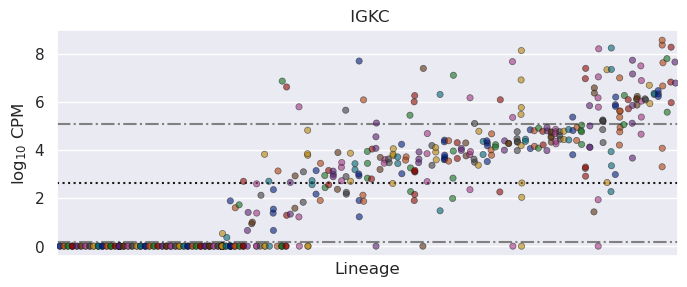

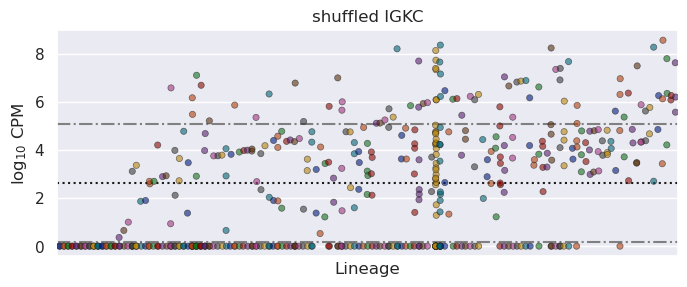

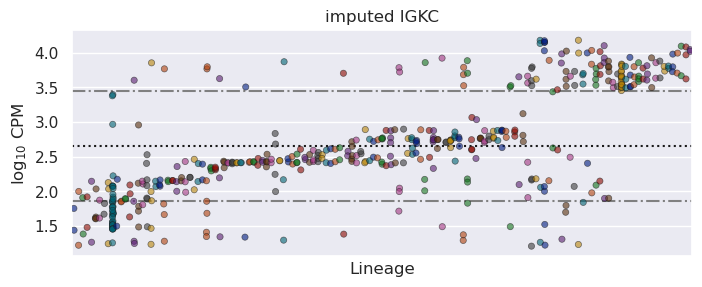

In [65]:
plotWaterall2('IGKC', 'CLONE', adata.obs, df, False, False, '', True)
plotWaterall2('IGKC', 'CLONE', adata.obs, df, False, True, 'shuffled', True)
plotWaterall2('IGKC', 'CLONE', adata.obs, _df, False, False, 'imputed', True)

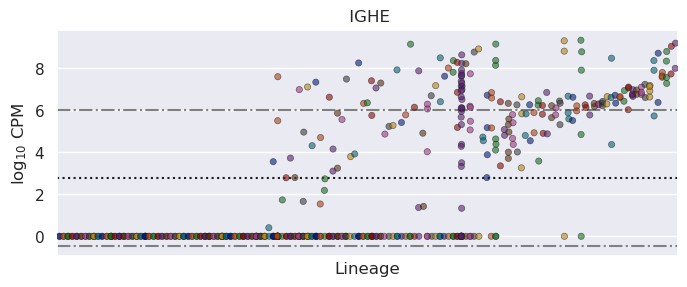

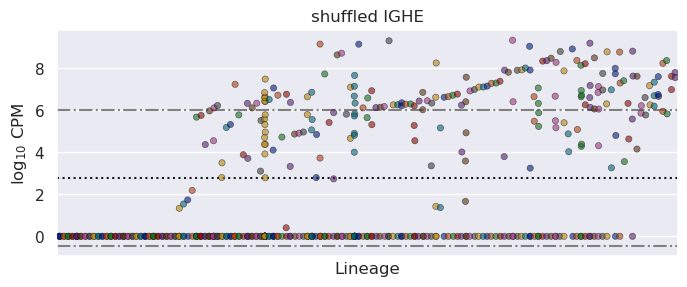

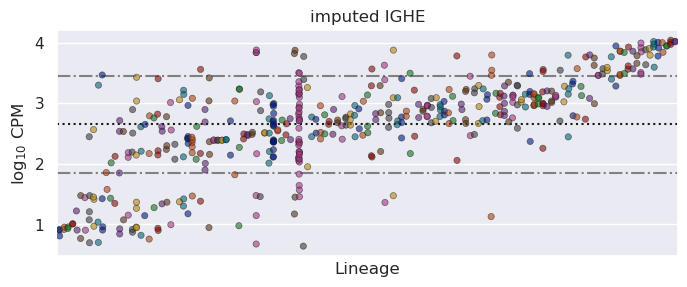

In [47]:
params = {}
plotWaterall2('IGHE', 'CLONE', adata.obs, df, False, False, '')
plotWaterall2('IGHE', 'CLONE', adata.obs, df, False, True, 'shuffled')
plotWaterall2('IGHE', 'CLONE', adata.obs, _df, False, False, 'imputed')

,CLONE,gene_expression
0,1401.0,0.270978
1,227.0,0.355358
2,863.0,0.284617
3,836.0,0.754404
4,660.0,0.465828
...,...,...
470,1687.0,0.443690
471,1149.0,0.351764
472,1618.0,1.058442
473,1538.0,0.670833


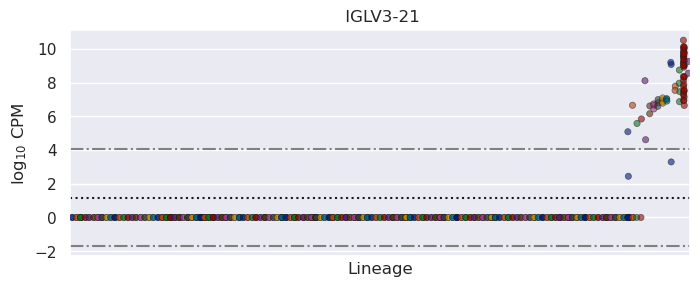

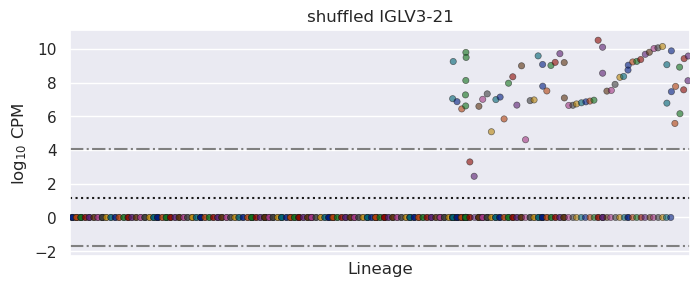

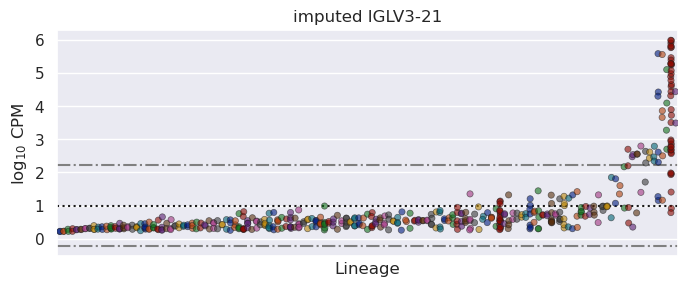

In [54]:
plotWaterall2('IGLV3-21', 'CLONE', adata.obs, df, False, False, '')
plotWaterall2('IGLV3-21', 'CLONE', adata.obs, df, False, True, 'shuffled')
plotWaterall2('IGLV3-21', 'CLONE', adata.obs, _df, False, False, 'imputed')

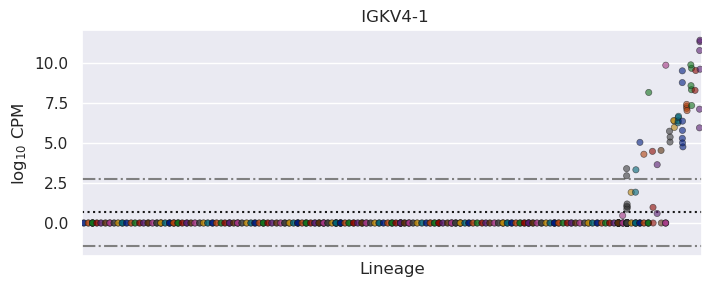

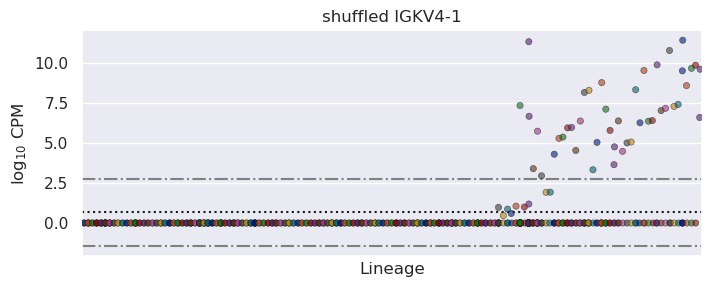

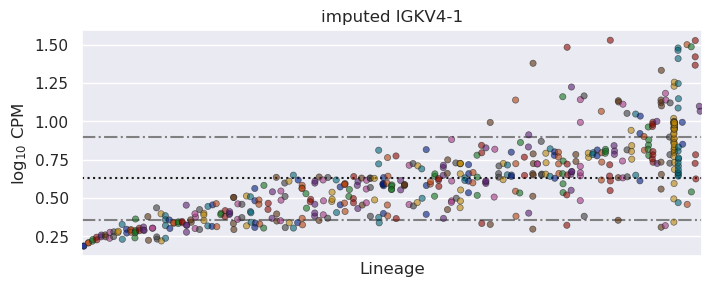

In [66]:
plotWaterall2('IGKV4-1', 'CLONE', adata.obs, df, False, False, '', True)
plotWaterall2('IGKV4-1', 'CLONE', adata.obs, df, False, True, 'shuffled', True)
plotWaterall2('IGKV4-1', 'CLONE', adata.obs, _df, False, False, 'imputed', True)

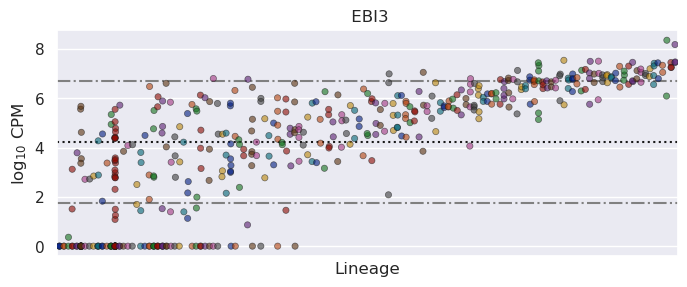

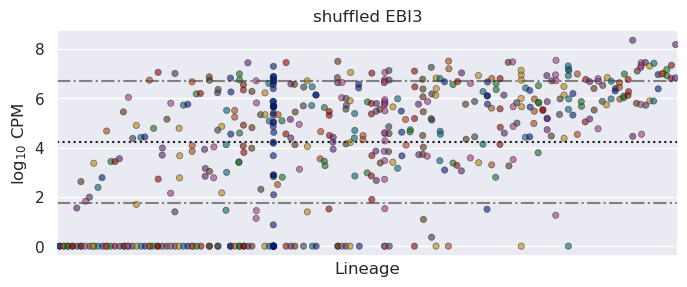

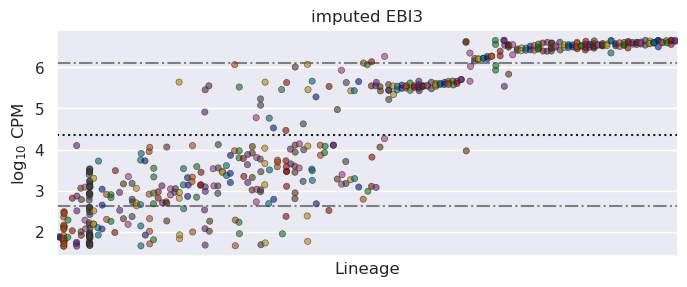

In [67]:

plotWaterall2('EBI3', 'CLONE', adata.obs, df, False, False, '', True)
plotWaterall2('EBI3', 'CLONE', adata.obs, df, False, True, 'shuffled', True)
plotWaterall2('EBI3', 'CLONE', adata.obs, _df, False, False, 'imputed', True)

In [48]:
clonal_genes

['IGLC3',
 'IGLV3-21',
 'IGLC2',
 'IGKC',
 'IGKV3-20',
 'IGHV5-10-1',
 'IGLV2-14',
 'ENSG00000277048',
 'IGHV3-30',
 'CCL17',
 'SELL',
 'IGKV4-1',
 'PRDM1',
 'EBI3',
 'LMNA',
 'FCER2',
 'CD74',
 'BCL2A1',
 'SLAMF1',
 'CCL22',
 'IGHV1-69D',
 'IGHV3-23',
 'TCL1A',
 'CADM1',
 'SWAP70',
 'HOPX',
 'SMARCC1',
 'IGHV1-46',
 'ATIC',
 'IGHE',
 'UCHL1',
 'IGHV4-34',
 'IGLV1-51',
 'PIP4K2A',
 'C6orf62',
 'ANXA6',
 'HLA-DQB1',
 'CD83',
 'MYO1G',
 'IL4I1',
 'MT-RNR2',
 'ODC1',
 'IGHV3-11',
 'IGLV2-23',
 'NAPSB',
 'AHCY',
 'LETM1',
 'SGK1',
 'IGHV1-69',
 'JCHAIN',
 'IGLV1-44',
 'MS4A1',
 'RBM38',
 'FAM46C',
 'AFF3',
 'BEX3',
 'LGALS1',
 'TSPAN33',
 'MVP',
 'CHD1',
 'GABPB1-AS1',
 'IGKV3-15',
 'CFL1',
 'TMSB4X',
 'NABP1',
 'TFPI2',
 'CD44',
 'HEBP2',
 'CD38',
 'BANK1',
 'IFNGR1',
 'CPNE5',
 'PTPN6',
 'NAA50',
 'IRAK1',
 'GRHPR',
 'TNFAIP8',
 'TVP23A',
 'BCL11A',
 'HSPH1',
 'BACH2',
 'AGFG1',
 'CD86',
 'HMGA1',
 'SRSF6',
 'KYNU',
 'MIR155HG',
 'COL9A2',
 'WRNIP1',
 'MRFAP1',
 'HNRNPM',
 'ADAR',
 'STAR

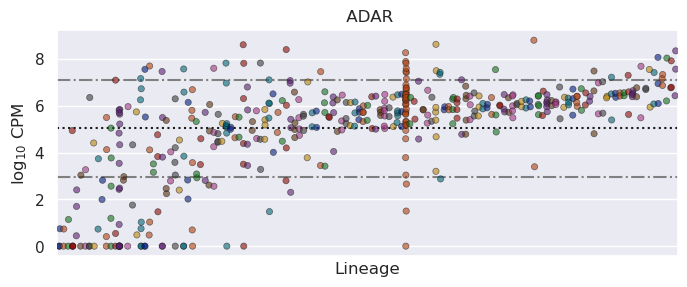

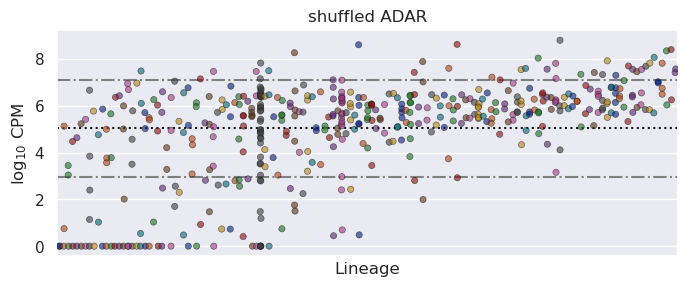

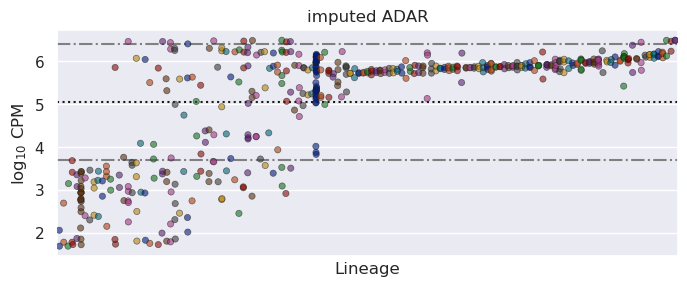

In [50]:
plotWaterall2('ADAR', 'CLONE', adata.obs, df, False, False, '')
plotWaterall2('ADAR', 'CLONE', adata.obs, df, False, True, 'shuffled')
plotWaterall2('ADAR', 'CLONE', adata.obs, _df, False, False, 'imputed')

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/pandas/core/indexing.py:845: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = _infer_fill_value(value)
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/pandas/core/indexing.py:966: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


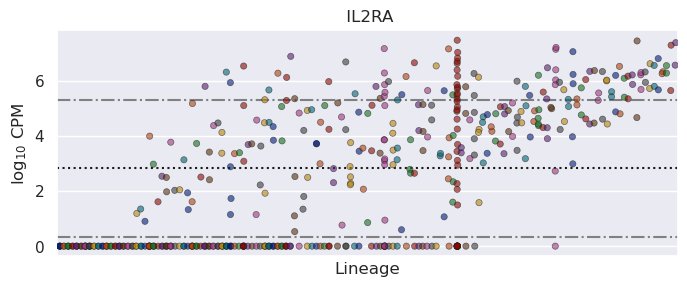

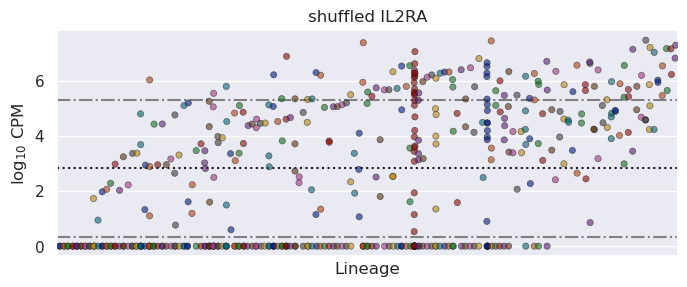

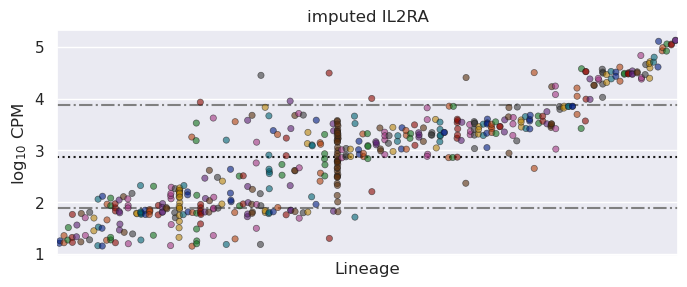

In [51]:
plotWaterall2('IL2RA', 'CLONE', adata.obs, df, False, False, '')
plotWaterall2('IL2RA', 'CLONE', adata.obs, df, False, True, 'shuffled')
plotWaterall2('IL2RA', 'CLONE', adata.obs, _df, False, False, 'imputed')

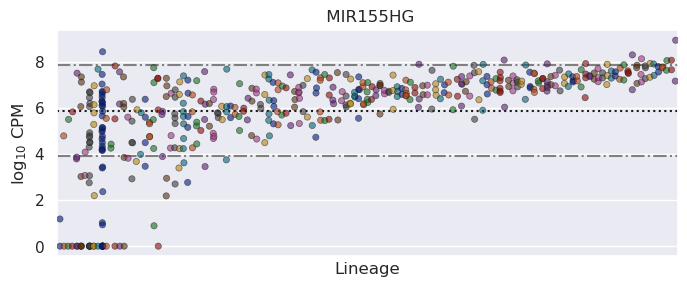

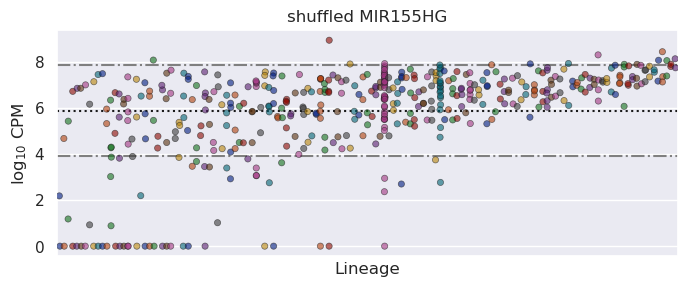

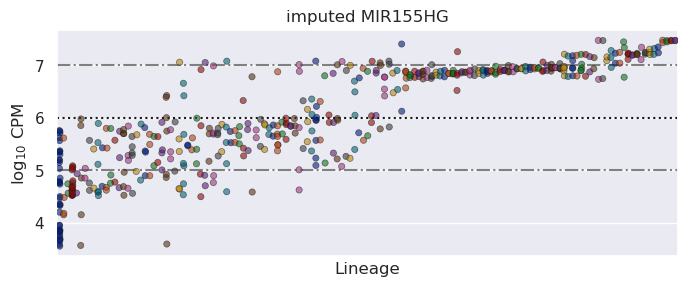

In [52]:
plotWaterall2('MIR155HG', 'CLONE', adata.obs, df, False, False, '')
plotWaterall2('MIR155HG', 'CLONE', adata.obs, df, False, True, 'shuffled')
plotWaterall2('MIR155HG', 'CLONE', adata.obs, _df, False, False, 'imputed')

In [ ]:
plotWaterall2('ADAR', 'CLONE', adata.obs, df, False, False, '')
plotWaterall2('ADAR', 'CLONE', adata.obs, df, False, True, 'shuffled')
plotWaterall2('ADAR', 'CLONE', adata.obs, _df, False, False, 'imputed')

# 

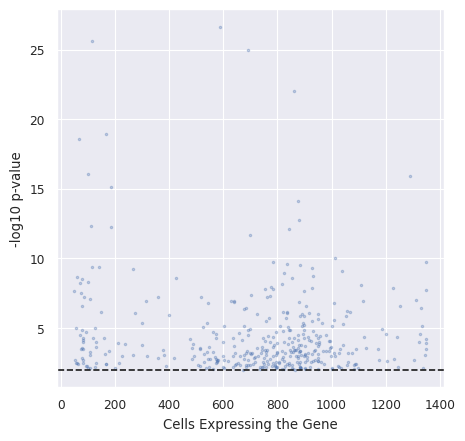

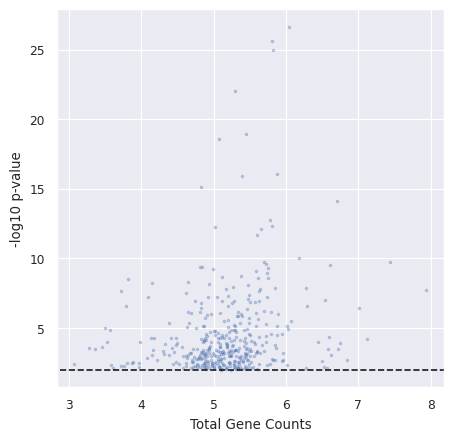

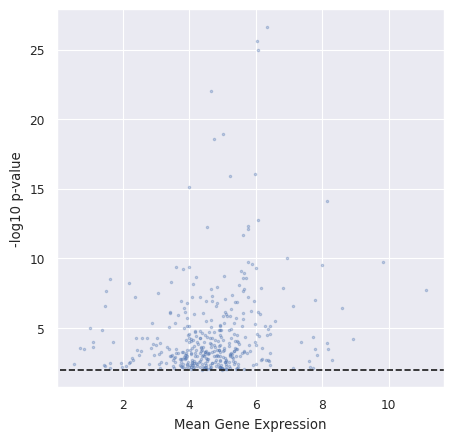

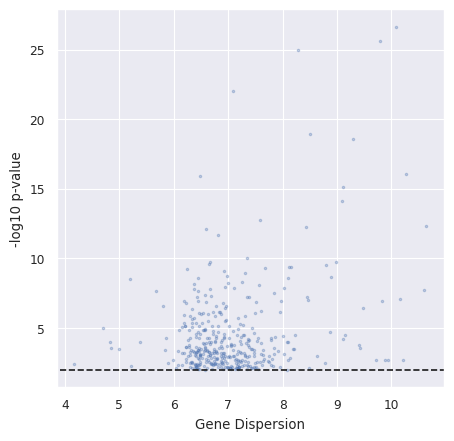

In [304]:
CLONE_tests = CLONE_tests[CLONE_tests.corrected_pvalue < 0.01]
sns.set(rc={'figure.figsize':(5, 5)})
sns.set_context(context='paper')
fig, ax = plt.subplots(1,1)

plt.scatter(x = CLONE_tests['n_cells'], y = -np.log10(CLONE_tests['corrected_pvalue']), alpha = 0.3, s = 3)
plt.axhline(y = 2, linestyle = '--', color = 'k', xmin = 0.004)
plt.ylabel('-log10 p-value')
plt.xlabel('Cells Expressing the Gene')
save_figure(fig, 'pvalbyCellsExpressingGene')

fig, ax = plt.subplots(1,1)
plt.scatter(x = np.log10(CLONE_tests['n_counts']), y = -np.log10(CLONE_tests['corrected_pvalue']), alpha = 0.3, s = 3)
plt.axhline(y = 2, linestyle = '--', color = 'k', xmin = 0.01)
plt.ylabel('-log10 p-value')
plt.xlabel('Total Gene Counts')
save_figure(fig, 'pvalbyGeneCounts')

fig, ax = plt.subplots(1,1)
plt.scatter(x = CLONE_tests['means'], y = -np.log10(CLONE_tests['corrected_pvalue']), alpha = 0.3, s = 3)
plt.axhline(y = 2, linestyle = '--', color = 'k', xmin = 0.01)
plt.ylabel('-log10 p-value')
plt.xlabel('Mean Gene Expression')
save_figure(fig, 'pvalbyMeanExpression')

fig, ax = plt.subplots(1,1)
plt.scatter(x = CLONE_tests['dispersions'], y = -np.log10(CLONE_tests['corrected_pvalue']), alpha = 0.3, s = 3)
plt.axhline(y = 2, linestyle = '--', color = 'k', xmin = 0.01)
plt.ylabel('-log10 p-value')
plt.xlabel('Gene Dispersion')
save_figure(fig, 'pvalbyDispersion')

Text(0.5, 0, '')

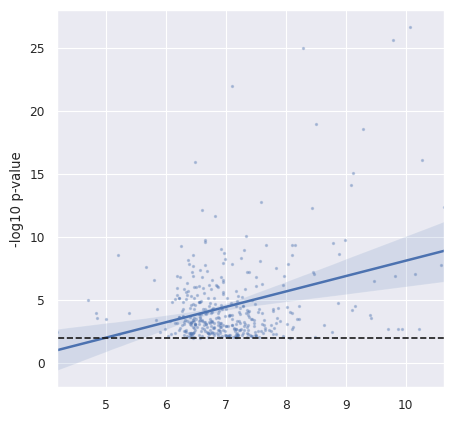

In [305]:
sns.regplot(x = CLONE_tests['dispersions'], y = -np.log10(CLONE_tests['corrected_pvalue']), scatter_kws={'alpha': 0.3, 's':2})
plt.axhline(y = 2, linestyle = '--', color = 'k', xmin = 0.004)
plt.ylabel('-log10 p-value')
plt.xlabel('')
